<a href="https://colab.research.google.com/github/Jyoti-Yadav2/R-for-bioinformatics/blob/main/Multiple_Alignment_and_Phylogenetic_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install R base
#Configure rpy2

In [ ]:
install.packages("BiocManager")
BiocManager::install("seqinr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'seqinr'”
Old packages: 'callr', 'dbplyr', 'httr2', 'openssl', 'pak', 'pkgload',
  'rstudioapi', 'selectr', 'sessioninfo', 'shiny', 'tinytex', 'withr', 'xfun',
  'xml2', 'xtable', 'zip'



In [ ]:
install.packages("rentrez")
library(rentrez)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(seqinr) # Function to fetch multiple UniProt/Swiss-Prot sequences via URL
retrieve_uniprot_seqs <- function(seqnames)
{
  myseqs <- list()
  for (i in 1:length(seqnames))
  {
    seqname <- seqnames[i]
    print(paste("Retrieving sequence", seqname, "..."))
    # Construct the modern UniProt REST API URL for FASTA format
    url <- paste0("https://rest.uniprot.org/uniprotkb/", seqname, ".fasta")
    # Safely try to read the fasta sequence from the internet
    tryCatch({
      fasta_data <- read.fasta(file = url, seqtype = "AA", as.string = FALSE)
      # Extract just the raw vector sequence array
      myseqs[[i]] <- fasta_data[[1]]
      },
      error = function(e)
      {
        print(paste("Failed to retrieve:", seqname, "- Error:", e$message))
        myseqs[[i]] <- NULL
        })
        }
        return(myseqs) }
        # Run the updated code
seqnames <- c("P06747", "P0C569", "O56773", "Q5VKP1")
seqs <- retrieve_uniprot_seqs(seqnames)
length(seqs)
seq1 <- seqs[[1]]
seq1 [1:20]
seq2 <- seqs[[2]]
seq2 [1:20]

[1] "Retrieving sequence P06747 ..."
[1] "Retrieving sequence P0C569 ..."
[1] "Retrieving sequence O56773 ..."
[1] "Retrieving sequence Q5VKP1 ..."


[1] 4

[1] "M" "S" "K" "I" "F" "V" "N" "P" "S" "A" "I" "R" "A" "G" "L" "A" "D" "L" "E"
[20] "M"

[1] "M" "S" "K" "D" "L" "V" "H" "P" "S" "L" "I" "R" "A" "G" "I" "V" "E" "L" "E"
[20] "M"

In [ ]:
write.fasta(seqs, seqnames, file="phosphoproteins.fasta")

In [ ]:
BiocManager::install("msa", ask = FALSE, update = FALSE)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'msa'”


In [ ]:
library(msa)
BiocManager::install("ape", ask = FALSE, update = FALSE)
# Install the 'ape' package
library(ape)
#Read your input protein fasta file
protein_seqs <- readAAStringSet("phosphoproteins.fasta")
#Execute ClustalW multiple alignment
protein_align <- msa(protein_seqs, method = "ClustalW")
#Convert alignment to an amino acid matrix class
matrix_align <- msaConvert(protein_align, type = "ape::AAbin")
#Export directly to PHYLIP sequential format
write.dna(matrix_align, file = "phosphoproteins.phy",
          format = "sequential")

Loading required package: Biostrings

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘packag

use default substitution matrix


In [ ]:
library(seqinr)
#Convert alignment to seqinr format
seqinr_align <- msaConvert(protein_align, type = "seqinr::alignment")
#Save it properly to a FASTA file using seqinr library(seqinr)
write.dna(seqinr_align, format = "fasta",
          file = "phosphoproteins.phy")

virusaln <- read.alignment(file = "phosphoproteins.phy", format = "fasta")

In [ ]:
virusaln$seq

[[1]]
[1] "4"

[[2]]
[1] "p0c569o567"

[[3]]
[1] "mskdlvhpsl"

[[4]]
[1] "na"

In [ ]:
#Created a multiple alignment of protein using CLUSTAL
#Reading a multiple alignment file into R
virusaln <- read.alignment(file = "clustalw.phy",
                           format = "phylip")

In [ ]:
virusaln$seq

[[1]]
[1] "mskdlvhpsliragivelemaeettdlinrtiesnqahlqgeplyvdslpedmsrlriedksrrtkteeeerdegsseednylsegqdplipfqnfldeigaravkrlktgegffrvwsalsddikgyvstnim-tsgerdtksiqiqteptasvssgnesrhdsesmhdpndkkdhtpdhdvvpdiesstdkgeirdiegevahqvaesfskkykfpsrssgiflwnfeqlkmnlddivkaamnvpgveriaekggklplrcilgfvaldsskrfrlladndkvarliqedinsymarleeae--"

[[2]]
[1] "mskglihpsairsglvdlemaeetvdlvhknladsqahlqgeplnvdslpedmrkmrltnapsereiieedeeeyssedeyylsqgqdpmvpfqnfldelgtqivrrmksgdgffkiwsaasedikgyvlstfm-kpetqatvskptqtdslsvprpsqgytsvprdkpsnsesqgggvkpkkvqksewtrdtdeisdiegevahqvaesfskkykfpsrssgiflwnfeqlkmnlddivktsmnvpgvdkiaekggklplrcilgfvsldsskrfrlladtdkvarlmqddihnymtrieeidhn"

[[3]]
[1] "mskifvnpsairagladlemaeetvdlinrniednqahlqgepievdnlpedmgrlhlddgkspnpgemakvgegkyredfqmdegedpsllfqsyldnvgvqivrqirsgerflkiwsqtveeiisyvavnfp-nppgkssedkstqttgrelkkettptpsqresqsskarmaaqtasgppalewsatneeddls-veaeiahqiaesfskkykfpsrssgillynfeqlkmnlddivkeaknvpgvtrlardgsklplrcvlgwvalanskkfqllvesnklskimqddlnrytsc-------"

[[4]]
[1] "mskslihpsdlragladiemadetvdlvyknlsegqahlqgepfdikdlpegvsklqisdnvrsdtspneysdeddeegedeyeevydpvsafqdfldetgsylisklkkgekikktwsevsrviysyvmsnfpprppkpttkdiavqadlkkpneiqkisehksksepsprepvvemhkhatle-----npeddegaleseiahqvaesyskkykfpskssgiflwnfeqlkmnlddivqvargvpgisqiverggklplrcmlgyvgletskrfrslvnqdklcklmqedlnaysvssnn----"

In [ ]:
printMultipleAlignment <- function(alignment, chunksize=60)
{
  require("Biostrings")
  # find the number of sequences in the alignment
  numseqs <- alignment$nb
  # find the length of the alignment
  alignmentlen <- nchar(alignment$seq[[1]])
  starts <- seq(1, alignmentlen, by=chunksize)
  n <- length(starts)
  #get the alignment for each of the sequences:
  aln <- vector()
  lettersprinted <- vector()
  for (j in 1:numseqs)
  {
    alignmentj <- alignment$seq[[j]]
    aln[j] <- alignmentj
    lettersprinted[j] <- 0
  }
  # print out the alignment in blocks of 'chunksize' columns:
  for (i in 1:n) { # for each of n chunks
   for (j in 1:numseqs)
   {
    alnj <- aln[j]
    chunkseqjaln <- substring (alnj, starts [i], starts [i]+chunksize-1)
    chunkseqjaln <- toupper (chunkseqjaln)
    # Find out how many gaps there are in chunkseqjaln:
    gapsj <- countPattern("-", chunkseqjaln)
    # countPattern() is from Biostrings package
    # Calculate how many residues of the first sequence we have printed so far in the alignment:
    lettersprinted[j] <- lettersprinted[j] + chunksize - gapsj
    print (paste (chunkseqjaln, lettersprinted[j]))
   }
   print (paste(' '))
  }
}

In [ ]:
printMultipleAlignment(virusaln, 60)

[1] "MSKDLVHPSLIRAGIVELEMAEETTDLINRTIESNQAHLQGEPLYVDSLPEDMSRLRIED 60"
[1] "MSKGLIHPSAIRSGLVDLEMAEETVDLVHKNLADSQAHLQGEPLNVDSLPEDMRKMRLTN 60"
[1] "MSKIFVNPSAIRAGLADLEMAEETVDLINRNIEDNQAHLQGEPIEVDNLPEDMGRLHLDD 60"
[1] "MSKSLIHPSDLRAGLADIEMADETVDLVYKNLSEGQAHLQGEPFDIKDLPEGVSKLQISD 60"
[1] " "
[1] "KSRRTKTEEEERDEGSSEEDNYLSEGQDPLIPFQNFLDEIGARAVKRLKTGEGFFRVWSA 120"
[1] "APSEREIIEEDEEEYSSEDEYYLSQGQDPMVPFQNFLDELGTQIVRRMKSGDGFFKIWSA 120"
[1] "GKSPNPGEMAKVGEGKYREDFQMDEGEDPSLLFQSYLDNVGVQIVRQIRSGERFLKIWSQ 120"
[1] "NVRSDTSPNEYSDEDDEEGEDEYEEVYDPVSAFQDFLDETGSYLISKLKKGEKIKKTWSE 120"
[1] " "
[1] "LSDDIKGYVSTNIM-TSGERDTKSIQIQTEPTASVSSGNESRHDSESMHDPNDKKDHTPD 179"
[1] "ASEDIKGYVLSTFM-KPETQATVSKPTQTDSLSVPRPSQGYTSVPRDKPSNSESQGGGVK 179"
[1] "TVEEIISYVAVNFP-NPPGKSSEDKSTQTTGRELKKETTPTPSQRESQSSKARMAAQTAS 179"
[1] "VSRVIYSYVMSNFPPRPPKPTTKDIAVQADLKKPNEIQKISEHKSKSEPSPREPVVEMHK 180"
[1] " "
[1] "HDVVPDIESSTDKGEIRDIEGEVAHQVAESFSKKYKFPSRSSGIFLWNFEQLKMNLDDIV 239"
[1] "PKKVQKSEWTRDTDEISDIEGEVAHQVAESFSKKYKFPSRSSGIFLWNFEQL

cleanAlignment() has 3 arguments (inputs):
the input alignment;
the minimum percent of letters in an alignment column must be nongap characters for column;
minimum percent of oairs of letters in alignment must be identical for column

In [ ]:
#Discarding very poorly conserved regions from an alignmen
cleanAlignment <- function(alignment, minpcnongap, minpcid)
{
  #make a copy of alignment to store new alignment in:
  newalignment<- alignment
  #find number of sequences in alignment
  numseqs <- alignment$nb
  #empty alignment in "newalignment"
  for (j in 1:numseqs) { newalignment$seq[[j]] <- ""}
  #find length of alignment
  alignmentlen <- nchar(alignment$seq[[1]])
  #look at each column of alignment in turn:
  for (i in 1:alignmentlen)
  {
    #see what percent of letters in this column are non-gaps:
    nongap <- 0
    for (j in 1:numseqs)
    {
      seqj <- alignment$seq[[j]] # Corrected typo here
      letterij <- substr(seqj,i,i)
      if (letterij != "-") { nongap <- nongap + 1}
    }
    pcnongap <- (nongap*100)/numseqs # Corrected variable name here
    #Only consider this column if atleast micpcnongap % of letters are not gaps:
    if (pcnongap >= minpcnongap)
    {
      #see what percent of pairs of letters in this column are identical:
      numpairs <- 0; numid <- 0
      #find letters in all of sequences in this column:
      for (j in 1:(numseqs-1))
      {
        seqj <- alignment$seq[[j]]
        letterij <- substr(seqj, i,i)
        for (k in (j+1):numseqs)
        {
          seqk <- alignment$seq[[k]] # Corrected variable name here
          letterkj <- substr(seqk, i,i)
          if (letterij != "-" && letterkj !="-")
          {
            numpairs <- numpairs + 1
            if (letterij == letterkj) { numid <- numid + 1}
          }
         }
      }
      pcid <- (numid*100)/ (numpairs)
      # Only consider this column if at least minpcid of the pairs of are identical:
      if (pcid >= minpcid)
      {
        for (j in 1:numseqs)
        {
          seqj <- alignment$seq[[j]]
          letterij <- substr(seqj,i,i)
          newalignmentj <- newalignment$seq[[j]]
          newalignmentj <- paste(newalignmentj,letterij,sep="")
          newalignment$seq[[j]] <- newalignmentj
        }
      }
    }
  }
  return(newalignment)
}

In [ ]:
cleanedvirusaln <- cleanAlignment(virusaln, 30, 30)

In [ ]:
printMultipleAlignment(cleanedvirusaln)

[1] "MSKLVHPSIRAGIVELEMAEETTDLIRTIQAHLQGEPVDLPEDMRLIDREEEDEGDPFQF 60"
[1] "MSKLIHPSIRSGLVDLEMAEETVDLVKNLQAHLQGEPVDLPEDMKMLNSEEEEQGDPFQF 60"
[1] "MSKFVNPSIRAGLADLEMAEETVDLIRNIQAHLQGEPVDLPEDMRLLDSAERDEGDPFQY 60"
[1] "MSKLIHPSLRAGLADIEMADETVDLVKNLQAHLQGEPIKLPEGVKLIDREEEEEVDPFQF 60"
[1] " "
[1] "LDEGVKGEFRWSSIGYVNIMSTSIQTHSDESGEDEEVAHQVAESFSKKYKFPSRSSGIFL 120"
[1] "LDEGVKGDFKWSSIGYVTFMPTSKQTSDSETDEDEEVAHQVAESFSKKYKFPSRSSGIFL 120"
[1] "LDNGVRGEFKWSVISYVNFPPSDKQTSSSSTDD-EEIAHQIAESFSKKYKFPSRSSGILL 119"
[1] "LDEGIKGEIKWSSISYVNFPPTDIQAHSS--DDAEEIAHQVAESYSKKYKFPSKSSGIFL 118"
[1] " "
[1] "WNFEQLKMNLDDIVKANVPGVIAEGGKLPLRCLGVLSKRFRLLADKVRLIQEDINYEE 180"
[1] "WNFEQLKMNLDDIVKSNVPGVIAEGGKLPLRCLGVLSKRFRLLADKVRLMQDDIHYEE 180"
[1] "YNFEQLKMNLDDIVKANVPGVLARGSKLPLRCLGVLSKKFQLLVNKLKIMQDDLNY-- 177"
[1] "WNFEQLKMNLDDIVQAGVPGIIVEGGKLPLRCLGVLSKRFRSLVDKLKLMQEDLNYNN 178"
[1] " "


In [ ]:
#Calculating genetic distances between protein seqs
virusdist <- dist.alignment(virusaln)
virusdist

           P0C569     O56773     P06747    
O56773      0.6371347                      
P06747      0.7293741  0.7270623           
Q5VKP1      0.7329135  0.7352146  0.7494290

To calculate genetic disrances between mRNA/DNA seqs

In [ ]:
retrieveseqs <- function(seqnames, database_id)
{
  myseqs <- list() # Make a list to store the sequences
  require("rentrez")
  require("seqinr") # Keep seqinr for read.fasta parsing
  for (i in 1:length(seqnames))
  {
    seqname <- seqnames[i]
    print(paste("Retrieving sequence", seqname, "from", database_id, "..."))
    tryCatch({
      # Fetch the sequence in FASTA format from NCBI E-utilities
      fasta_string <- rentrez::entrez_fetch(db = database_id, id = seqname,
      rettype = "fasta", retmode = "text")

      # Use seqinr::read.fasta to parse the FASTA string
      # textConnection allows treating the string as a file
      con <- textConnection(fasta_string)
      fasta_data <- read.fasta(con, seqtype = "DNA",
      as.string = FALSE)
      # Assuming nucleotide (DNA) sequences for GenBank
      close(con)

      # Extract just the raw vector sequence array
      myseqs[[i]] <- fasta_data[[1]]
      },
      error = function(e)
      {
        print(paste("Failed to retrieve:", seqname, "- Error:", e$message))
        myseqs[[i]] <- NULL # Assign NULL if retrieval fails
      })
  }
  return(myseqs)
}

In [ ]:
seqnames <- c("AF049118", "AF049114", "AF049119", "AF049115")
seqs <- retrieveseqs(seqnames, database_id = "nuccore")

# Display the lengths of the retrieved sequences to confirm retrieval
if (length(seqs) > 0) {
  for (i in 1:length(seqs)) {
    if (!is.null(seqs[[i]])) {
      print(paste("Length of sequence", seqnames[i], ":", length(seqs[[i]])))
    } else {
      print(paste("Sequence", seqnames[i], "was not retrieved."))
    }
  }
} else {
  print("No sequences were retrieved.")
}
write.fasta(seqs, seqnames, file="virusmRNA.fasta")

[1] "Retrieving sequence AF049118 from nuccore ..."
[1] "Retrieving sequence AF049114 from nuccore ..."
[1] "Retrieving sequence AF049119 from nuccore ..."
[1] "Retrieving sequence AF049115 from nuccore ..."
[1] "Length of sequence AF049118 : 1083"
[1] "Length of sequence AF049114 : 1016"
[1] "Length of sequence AF049119 : 1010"
[1] "Length of sequence AF049115 : 990"


In [ ]:
virusmRNAaln <- read.alignment(file="virusmRNA.phy", format = "phylip")

In [ ]:
virusmRNAalnbin <- as.DNAbin(virusmRNAaln)
virusmRNAdist <- dist.dna(virusmRNAalnbin)
virusmRNAdist

          AF049114  AF049119  AF049118
AF049119 0.3383295                    
AF049118 0.5246658 0.5624672          
AF049115 0.7667630 0.7518955 0.8385196

Building an unrooted phylogenetic tree for protein seqs by 'Neighbour-joining algorithm'

In [ ]:
unrootedNJtree <- function(alignment, type)
{
  # this function requires the ape and seqinR packages:
  require ("ape")
  require("seqinr")
  # define a function for making a tree:
  makemytree <- function (alignmentmat)
  {
    alignment <- ape::as.alignment (alignmentmat)
    if (type == "protein")
    {
      mydist <- dist.alignment (alignment)
    }
    else if (type == "DNA")
    {
      alignmentbin <- as.DNAbin(alignment)
      mydist <- dist.dna (alignmentbin)
    }
    mytree <- nj (mydist)
    mytree <- makeLabel (mytree, space="")
    # get rid of spaces in tip names.
    return (mytree)
  }
  #infer a tree
  mymat <- as.matrix.alignment (alignment)
  mytree <- makemytree (mymat)
  #bootstrao the tree
  myboot <- boot.phylo(mytree, mymat, makemytree)
  #plot the tree:
  plot.phylo (mytree, type="u") #plot unrooted phylogenetic tree
  nodelabels (myboot, cex=0.7) #plot bootstrap values
  mytree$node.label <- myboot #make bootstrap vslues be note labels
  return (mytree)
}

Running bootstraps:       100 / 100
Calculating bootstrap values... done.


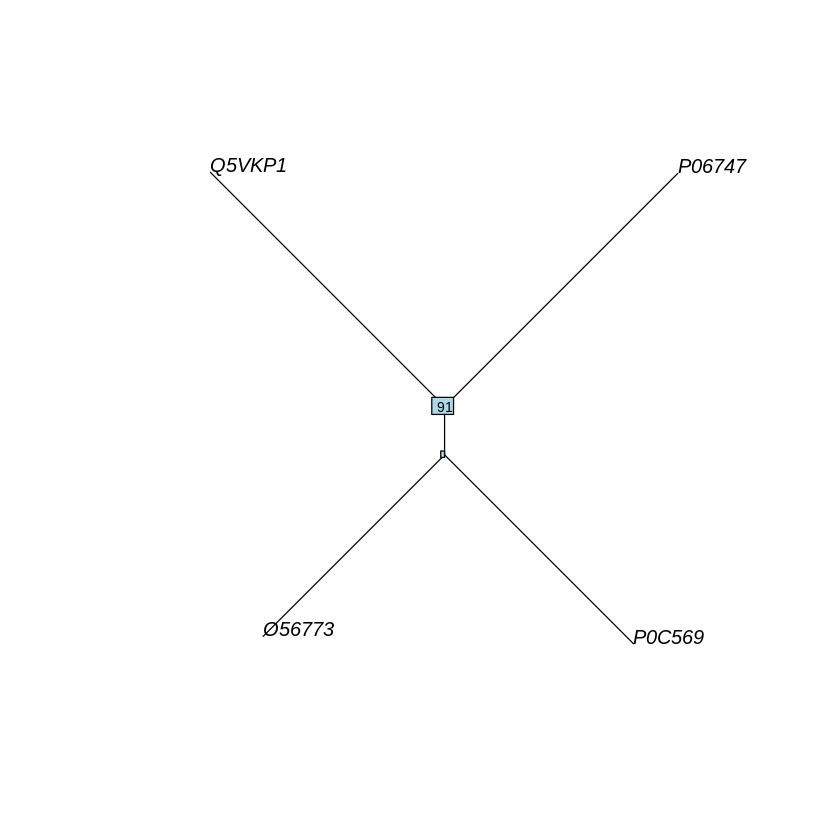

In [ ]:
cleanedvirusalntree <- unrootedNJtree(cleanedvirusaln, type="protein")

Running bootstraps:       100 / 100
Calculating bootstrap values... done.


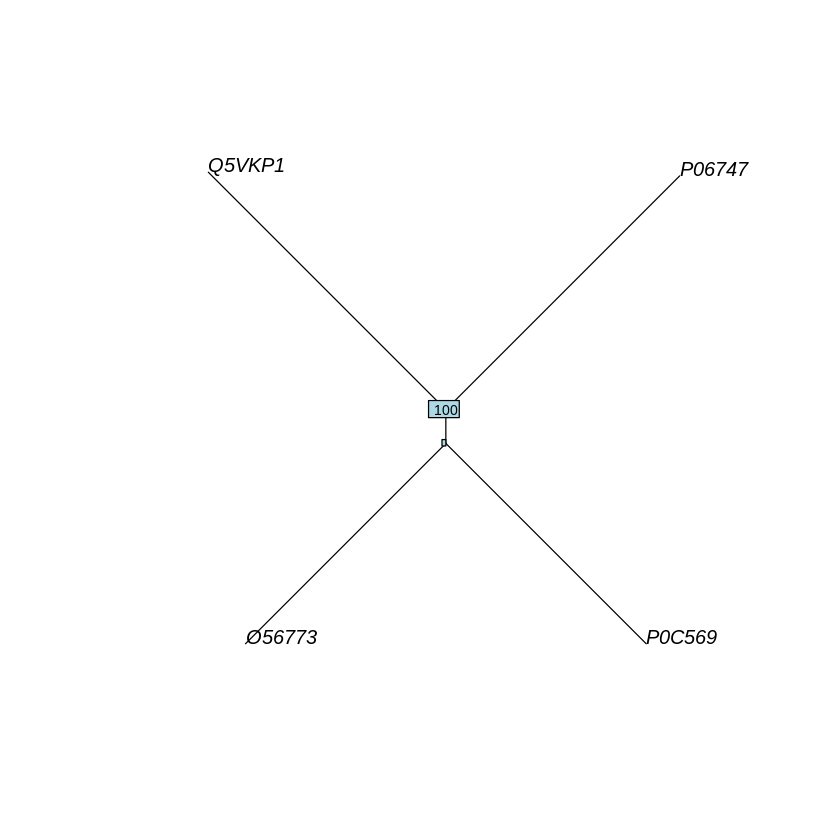

In [ ]:
virusalntree <- unrootedNJtree(virusaln, type = "protein")

Built rooted phylogenetic tree for protein sequences


In [ ]:
seqnames <- c("Q10572","E3M2K8","A8WS01","Q9VT99")
seqs <- retrieve_uniprot_seqs(seqnames)

[1] "Retrieving sequence Q10572 ..."
[1] "Retrieving sequence E3M2K8 ..."
[1] "Retrieving sequence A8WS01 ..."
[1] "Retrieving sequence Q9VT99 ..."


In [ ]:
write.fasta(seqs, seqnames, file="fox1.fasta")

In [ ]:
fox1aln <- read.alignment(file="fox1.phy", format="phylip")

In [ ]:
rootedNJtree <- function(alignment, theoutgroup, type)
{
  #load ape and seqinR packages:
  require("ape")
  require("seqinr")
  #define a function for making a tree
  makemytree <- function(alignmentmat)
  {
    alignment <- ape::as.alignment(alignmentmat)
    if (type == "protein")
    {
      mydist <- dist.alignment(alignment)
    }
    else if (type == "DNA")
    {
      alignmentbin <- as.DNAbin(alignment)
    }
    mytree <- nj(mydist)
    mytree1 <- makeLabel(mytree, space = "") #get rid of soaces in tip names
    myrootedtree <- root(mytree1, theoutgroup, r=TRUE)
    return(myrootedtree)
  }
  #infer a tree
  mymat <- as.matrix.alignment(alignment)
  myrootedtree <- makemytree(mymat)
  #bootstrap the tree
  myboot <- boot.phylo(myrootedtree, mymat, makemytree)
  #plot the tree:
  plot.phylo(myrootedtree,type = "p") #plot rooted phylogenetic tree
  nodelabels(myboot,cex=0.7)  #plot bootstrap values
  myrootedtree$node.label <- myboot #make bootstrap values be node labels
  return(myrootedtree)
}

Running bootstraps:       100 / 100
Calculating bootstrap values... done.


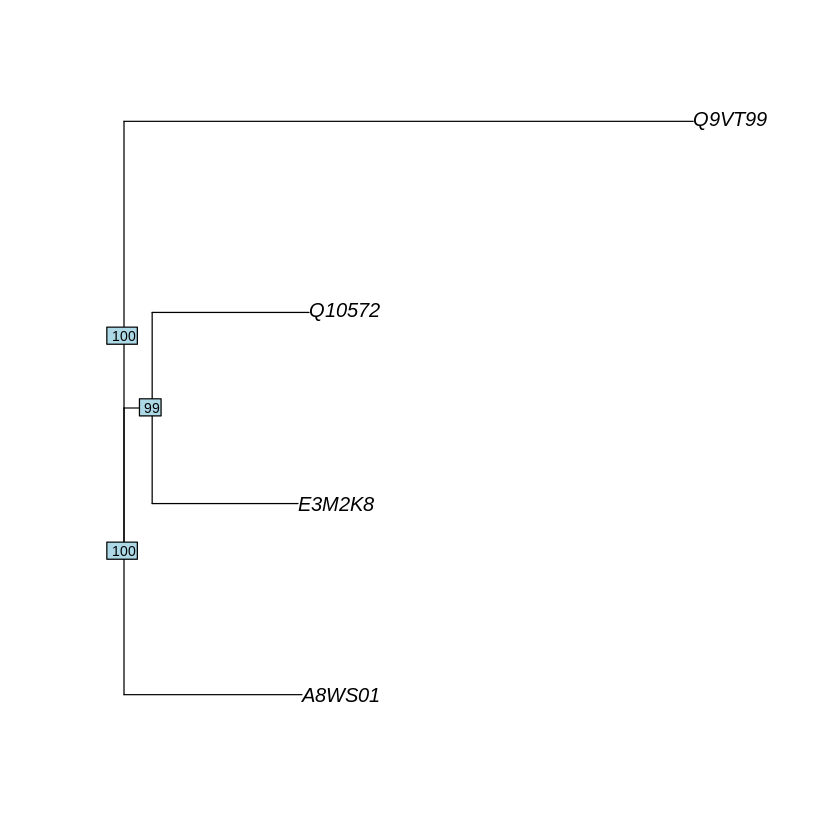

In [ ]:
fox1alntree <- rootedNJtree(fox1aln,"Q9VT99", type = "protein")

**built phylogenetic tree for DNA or mRNA seqs** (for primates) few mutations occured since they diverged, hence not enough signal to use for protein phylogenetic analysis

Running bootstraps:       100 / 100
Calculating bootstrap values... done.


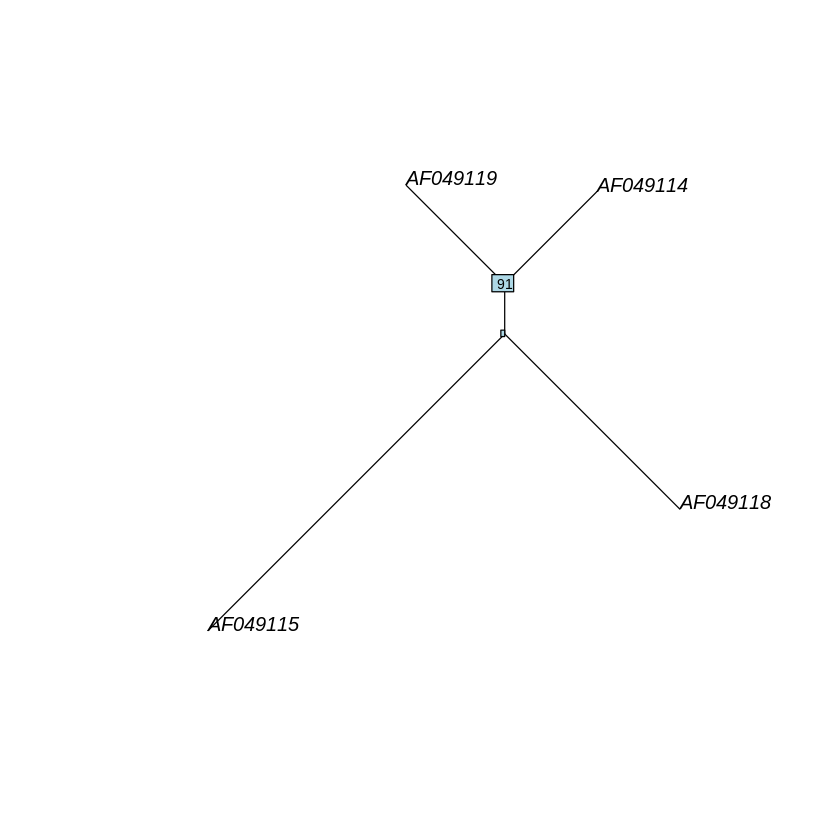

In [ ]:
virusmRNAaln <- read.alignment(file="virusmRNA.phy", format = "phylip")
virusmRNAalntree <- unrootedNJtree(virusmRNAaln, type="DNA")

In [ ]:
write.tree(virusmRNAalntree, "virusmRNA.tree")